# RQ2 — Geographic View: Eindhoven Neighbourhood Maps

**Research Question 2:** *What facilities need to grow faster, or what other
considerable measures should the municipality of Eindhoven take to accommodate
the growth in population?*

The companion notebook [`rq2_analysis.ipynb`](rq2_analysis.ipynb) answered RQ2
with charts. This notebook puts the same SPARQL-derived metrics **on a map of
Eindhoven**, so the geography of population pressure and facility access is
visible directly.

Each neighbourhood is drawn as a **choropleth ("heatmap") polygon**, coloured by
an RQ2 metric pulled live from the knowledge graph (`data/processed/data.ttl`).

**Boundaries.** `data/geo/eindhoven_buurten.geojson` — the municipality's own
neighbourhood boundaries (gemeente Eindhoven open data portal). It contains
**116 buurten whose names match our 116 data neighbourhoods exactly** (same
source organisation, Onderzoek040), so the spatial join is lossless — no fuzzy
name matching required.

In [1]:
!pip install rdflib geopandas mapclassify

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize, TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from rdflib import Graph

plt.rcParams["figure.dpi"] = 110

In [3]:
# Knowledge graph (same source the analysis notebook queries).
g = Graph()
g.parse("../data/processed/data.ttl", format="turtle")
print(f"Knowledge graph: {len(g):,} triples")

Knowledge graph: 71,739 triples


In [4]:
def run_query(sparql: str) -> pd.DataFrame:
    """Run a SPARQL SELECT and return a typed DataFrame (unbound -> NaN)."""
    res = g.query(sparql)
    cols = [str(v) for v in res.vars]
    rows = [[(b.get(v).toPython() if b.get(v) is not None else None) for v in res.vars]
            for b in res.bindings]
    df = pd.DataFrame(rows, columns=cols)
    for c in df.columns:
        coerced = pd.to_numeric(df[c], errors="coerce")
        if coerced.notna().sum() >= df[c].notna().sum():
            df[c] = coerced
    return df

In [5]:
# Neighbourhood polygons. Reproject to RD New (EPSG:28992, metres) so the map
# has the correct shape/aspect for the Netherlands.
gdf = gpd.read_file("../data/geo/eindhoven_buurten.geojson").to_crs(28992)
print(f"{len(gdf)} polygons | crs {gdf.crs}")
gdf[["buurtnaam", "wijknaam", "stadsdeelnaam"]].head(3)

116 polygons | crs EPSG:28992


,buurtnaam,wijknaam,stadsdeelnaam
0,Vaartbroek,Wijk Dommelbeemd,Stadsdeel Woensel-Noord
1,Poeijers,Wijk Putten,Stadsdeel Stratum
2,Karpen,Wijk Oud-Tongelre,Stadsdeel Tongelre


## RQ2 metrics per neighbourhood

These queries deliberately use `OPTIONAL` and **no growth filter**, so every
neighbourhood is returned (coloured where data exists, grey where it does not) —
appropriate for a map, where we want full coverage rather than the strict joins
used for the ranked tables in the analysis notebook.

In [6]:
# Population in 2015 and 2025.
pop = run_query("""
PREFIX ein: <http://eindhoven.nl/livability/>
SELECT ?name ?pop2015 ?pop2025 WHERE {
  ?nb ein:hasName ?name .
  OPTIONAL { ?nb ein:hasObservation ?a . ?a ein:inYear 2015 ; ein:population ?pop2015 . }
  OPTIONAL { ?nb ein:hasObservation ?b . ?b ein:inYear 2025 ; ein:population ?pop2025 . }
}""")

# 2025 distances to the seven essential facilities (+ hospital for context).
fac = run_query("""
PREFIX ein: <http://eindhoven.nl/livability/>
SELECT ?name ?supermarket ?groceries ?gp ?pharmacy ?primarySchool ?daycare ?train ?hospital
WHERE {
  ?nb ein:hasName ?name ; ein:hasObservation ?o .
  ?o ein:inYear 2025 .
  OPTIONAL { ?o ein:distSupermarket    ?supermarket . }
  OPTIONAL { ?o ein:distDailyGroceries ?groceries . }
  OPTIONAL { ?o ein:distGpPractice     ?gp . }
  OPTIONAL { ?o ein:distPharmacy       ?pharmacy . }
  OPTIONAL { ?o ein:distPrimarySchool  ?primarySchool . }
  OPTIONAL { ?o ein:distDaycare        ?daycare . }
  OPTIONAL { ?o ein:distTrainStation   ?train . }
  OPTIONAL { ?o ein:distHospital       ?hospital . }
}""")

# Housing: dwellings 2015/2025 and 2025 occupancy.
house = run_query("""
PREFIX ein: <http://eindhoven.nl/livability/>
SELECT ?name ?dw2015 ?dw2025 ?occ2025 WHERE {
  ?nb ein:hasName ?name .
  OPTIONAL { ?nb ein:hasObservation ?a . ?a ein:inYear 2015 ; ein:totalDwellings ?dw2015 . }
  OPTIONAL { ?nb ein:hasObservation ?b . ?b ein:inYear 2025 ;
             ein:totalDwellings ?dw2025 ; ein:pctOccupied ?occ2025 . }
}""")

metrics = pop.merge(fac, on="name", how="outer").merge(house, on="name", how="outer")

ess = ["supermarket", "groceries", "gp", "pharmacy", "primarySchool", "daycare", "train"]
metrics["pop_growth"]      = metrics["pop2025"] - metrics["pop2015"]
metrics["avg_essential"]   = metrics[ess].mean(axis=1)
metrics["dwelling_growth"] = metrics["dw2025"] - metrics["dw2015"]
# people added beyond new dwellings (positive => housing lagged population)
metrics["housing_gap"]     = metrics["pop_growth"] - metrics["dwelling_growth"]
print(f"metrics rows: {len(metrics)}")
metrics[["name", "pop_growth", "avg_essential", "housing_gap", "occ2025"]].head()

metrics rows: 116


,name,pop_growth,avg_essential,housing_gap,occ2025
0,'t Hofke,201.0,1.042857,-199.0,0.97
1,'t Hool,142.0,1.214286,125.0,0.96
2,Achtse Barrier-Gunterslaer,6.0,1.242857,3.0,0.98
3,Achtse Barrier-Hoeven,-184.0,1.471429,-186.0,0.99
4,Achtse Barrier-Spaaihoef,-129.0,1.271429,-131.0,0.99


In [7]:
# Spatial join (lossless: names match 1:1) and coverage report.
gdf = gdf.merge(metrics, left_on="buurtnaam", right_on="name", how="left")
for c in ["pop_growth", "avg_essential", "housing_gap", "occ2025"]:
    print(f"{c:15s}: {gdf[c].notna().sum()}/{len(gdf)} neighbourhoods coloured")

pop_growth     : 109/116 neighbourhoods coloured
avg_essential  : 111/116 neighbourhoods coloured
housing_gap    : 101/116 neighbourhoods coloured
occ2025        : 102/116 neighbourhoods coloured


In [8]:
# Reusable choropleth helper: grey base for missing, coloured polygons on top,
# a tidy colorbar, and optional diverging norm centred on zero.
def choropleth(ax, col, title, cmap="magma_r", diverging=False, cbar_label=""):
    data = gdf[col]
    vmin, vmax = np.nanmin(data), np.nanmax(data)
    if diverging and vmin < 0 < vmax:
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)
    gdf.plot(ax=ax, color="#e9e9e9", edgecolor="white", linewidth=0.35)
    gdf.dropna(subset=[col]).plot(ax=ax, column=col, cmap=cmap, norm=norm,
                                  edgecolor="white", linewidth=0.35)
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_axis_off()
    sm = cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    cax = make_axes_locatable(ax).append_axes("right", size="4%", pad=0.1)
    cb = ax.figure.colorbar(sm, cax=cax); cb.set_label(cbar_label, fontsize=9)
    return ax

## Map 1 — Where is the population pressure? (growth 2015 → 2025)

Red neighbourhoods gained residents; blue lost them. This is the demand side of
RQ2 — the places the municipality must accommodate.

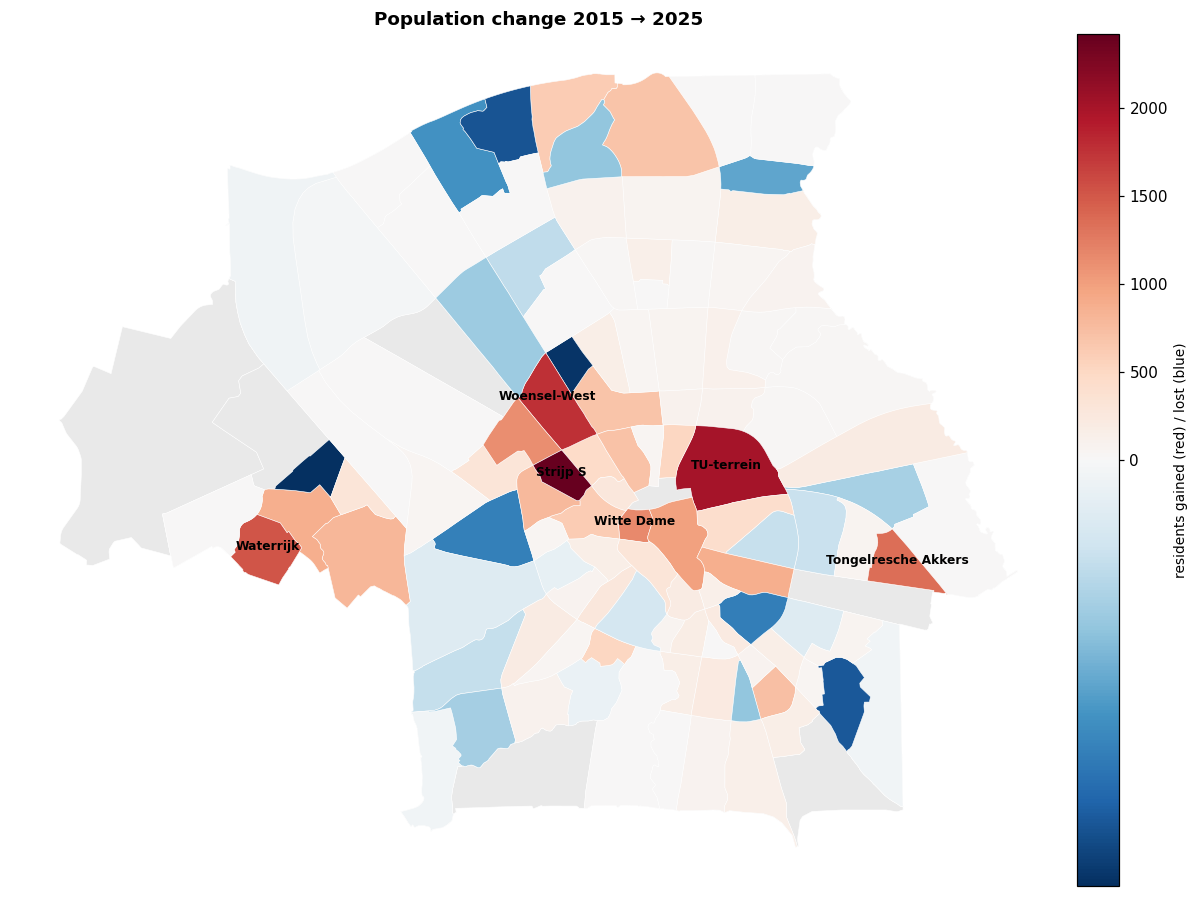

In [9]:
fig, ax = plt.subplots(figsize=(11, 10))
choropleth(ax, "pop_growth", "Population change 2015 → 2025",
           cmap="RdBu_r", diverging=True, cbar_label="residents gained (red) / lost (blue)")
# label the biggest gainers
for _, r in gdf.nlargest(6, "pop_growth").iterrows():
    p = r.geometry.representative_point()
    ax.annotate(r["buurtnaam"], (p.x, p.y), fontsize=8, ha="center", weight="bold")
plt.tight_layout(); plt.show()

## Map 2 — Where is facility access worst? (avg distance to 7 essentials, 2025)

Darker = further, on average, from a supermarket, daily groceries, GP, pharmacy,
primary school, daycare and train station. This is the supply side of RQ2.

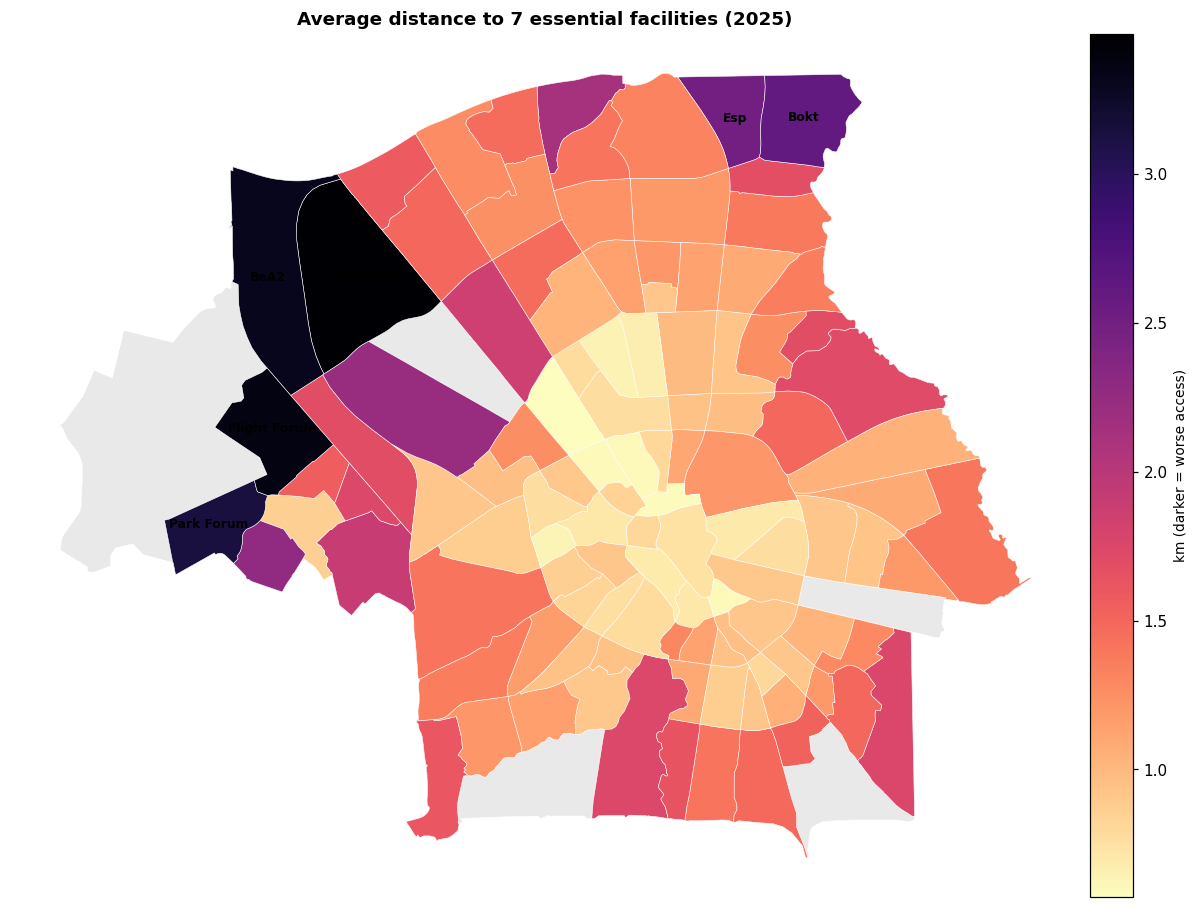

In [10]:
fig, ax = plt.subplots(figsize=(11, 10))
choropleth(ax, "avg_essential", "Average distance to 7 essential facilities (2025)",
           cmap="magma_r", cbar_label="km (darker = worse access)")
for _, r in gdf.nlargest(6, "avg_essential").iterrows():
    p = r.geometry.representative_point()
    ax.annotate(r["buurtnaam"], (p.x, p.y), fontsize=8, ha="center", weight="bold")
plt.tight_layout(); plt.show()

## Map 3 — Access by facility type (2025)

The composite hides which facility is the problem. These small multiples map each
essential facility separately (note each has its own colour scale).

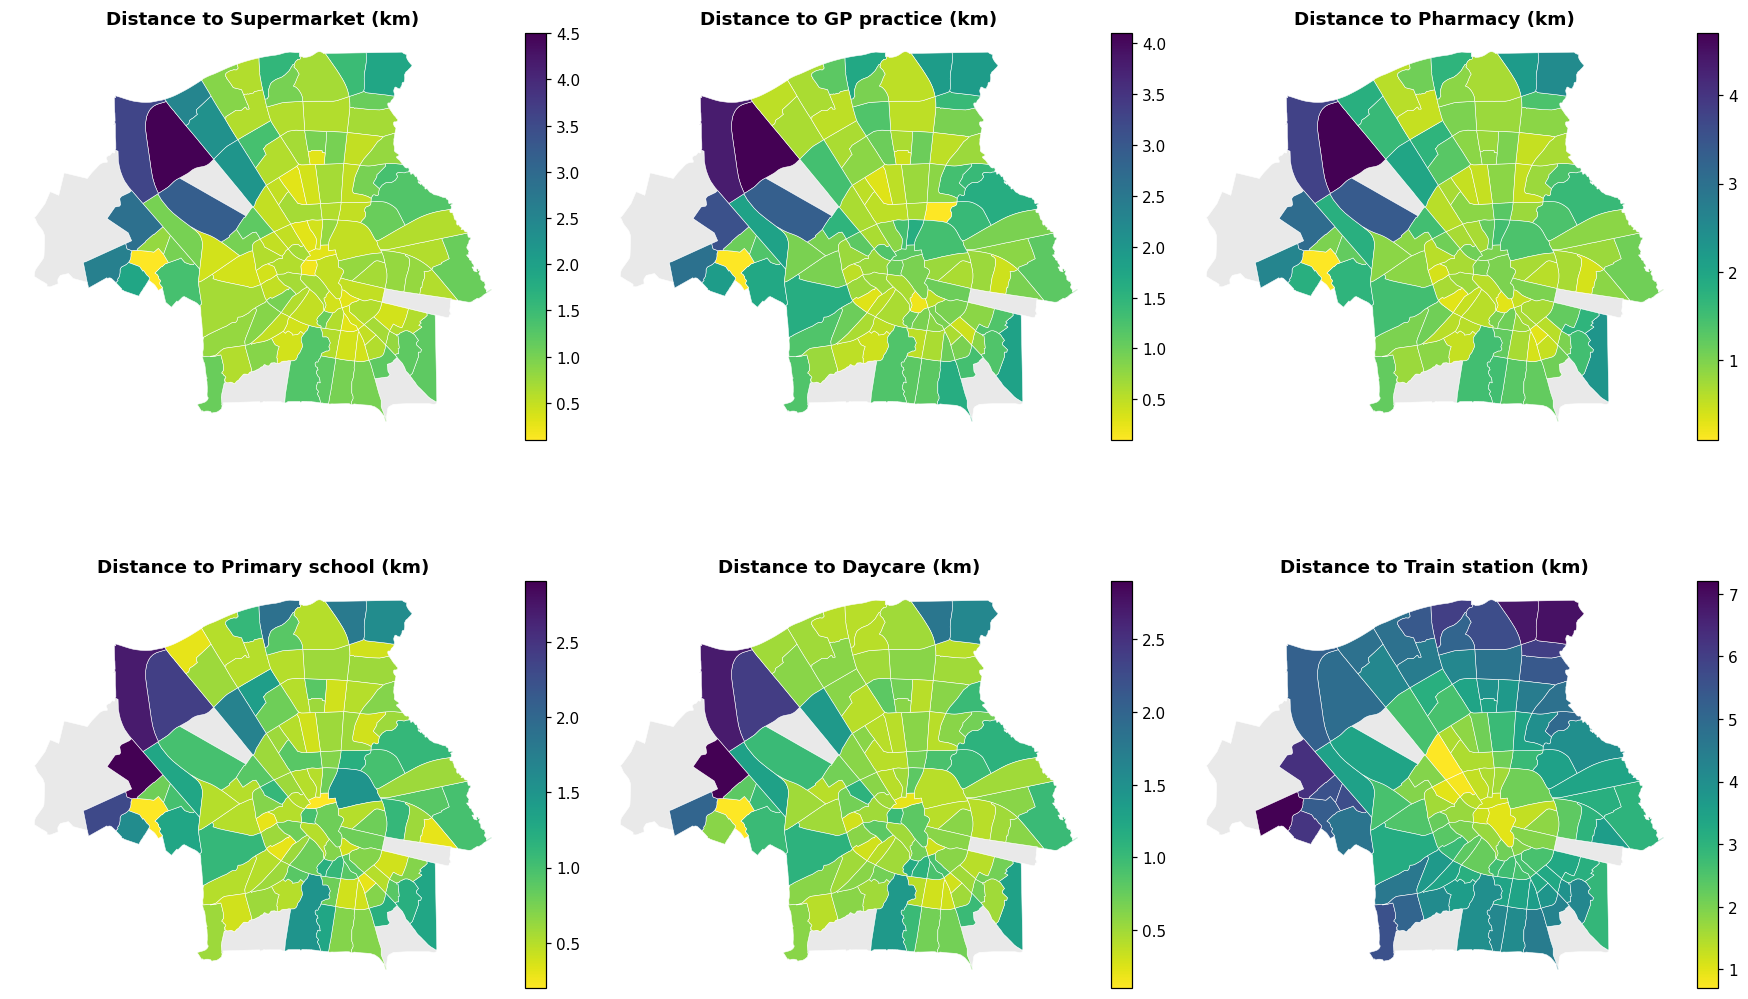

In [11]:
panels = [("supermarket", "Supermarket"), ("gp", "GP practice"),
          ("pharmacy", "Pharmacy"), ("primarySchool", "Primary school"),
          ("daycare", "Daycare"), ("train", "Train station")]
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
for (col, label), ax in zip(panels, axes.ravel()):
    choropleth(ax, col, f"Distance to {label} (km)", cmap="viridis_r")
plt.tight_layout(); plt.show()

## Map 4 — Housing gap (population growth minus dwelling growth)

Red = the neighbourhood added **more residents than dwellings** between 2015 and
2025 (housing supply lagged demand); blue = housing kept up or got ahead. This is
the "other considerable measures" (housing) half of RQ2.

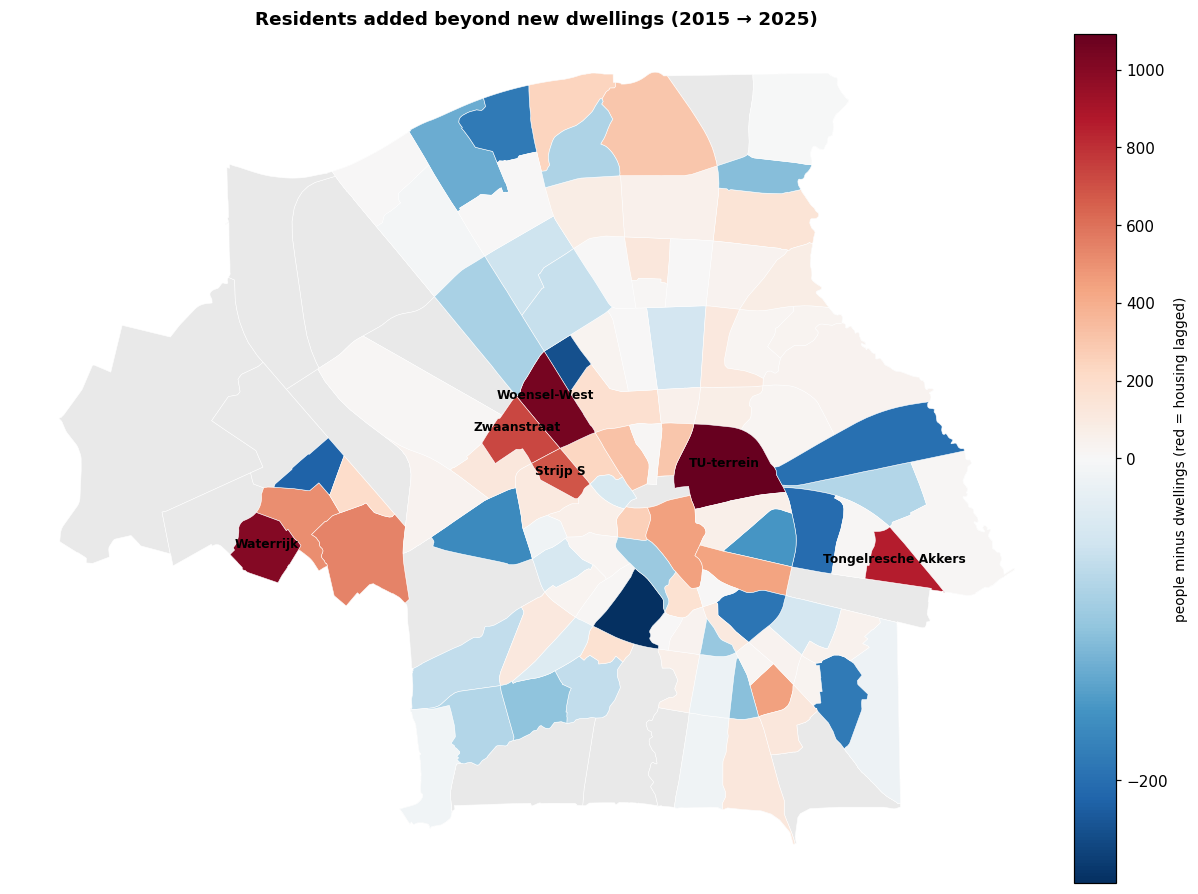

In [12]:
fig, ax = plt.subplots(figsize=(11, 10))
choropleth(ax, "housing_gap", "Residents added beyond new dwellings (2015 → 2025)",
           cmap="RdBu_r", diverging=True,
           cbar_label="people minus dwellings (red = housing lagged)")
for _, r in gdf.nlargest(6, "housing_gap").iterrows():
    p = r.geometry.representative_point()
    ax.annotate(r["buurtnaam"], (p.x, p.y), fontsize=8, ha="center", weight="bold")
plt.tight_layout(); plt.show()

## Map 5 — New-resident access burden (investment priority)

To turn "high growth **and** poor access" into a single surface we use the
**new-resident access burden**:

$$\text{burden} = \max(\text{population growth}, 0)\;\times\;\text{avg essential distance (km)}$$

measured in **resident·km** — how many *new* residents arrived, multiplied by how
far they sit from essentials. Multiplying by the number of people (rather than
adding z-scores) keeps near-empty industrial/airport edge zones — which have huge
distances but almost nobody — out of the top, and surfaces the neighbourhoods
where growth and poor access genuinely coincide. This is the spatial answer to
RQ2.

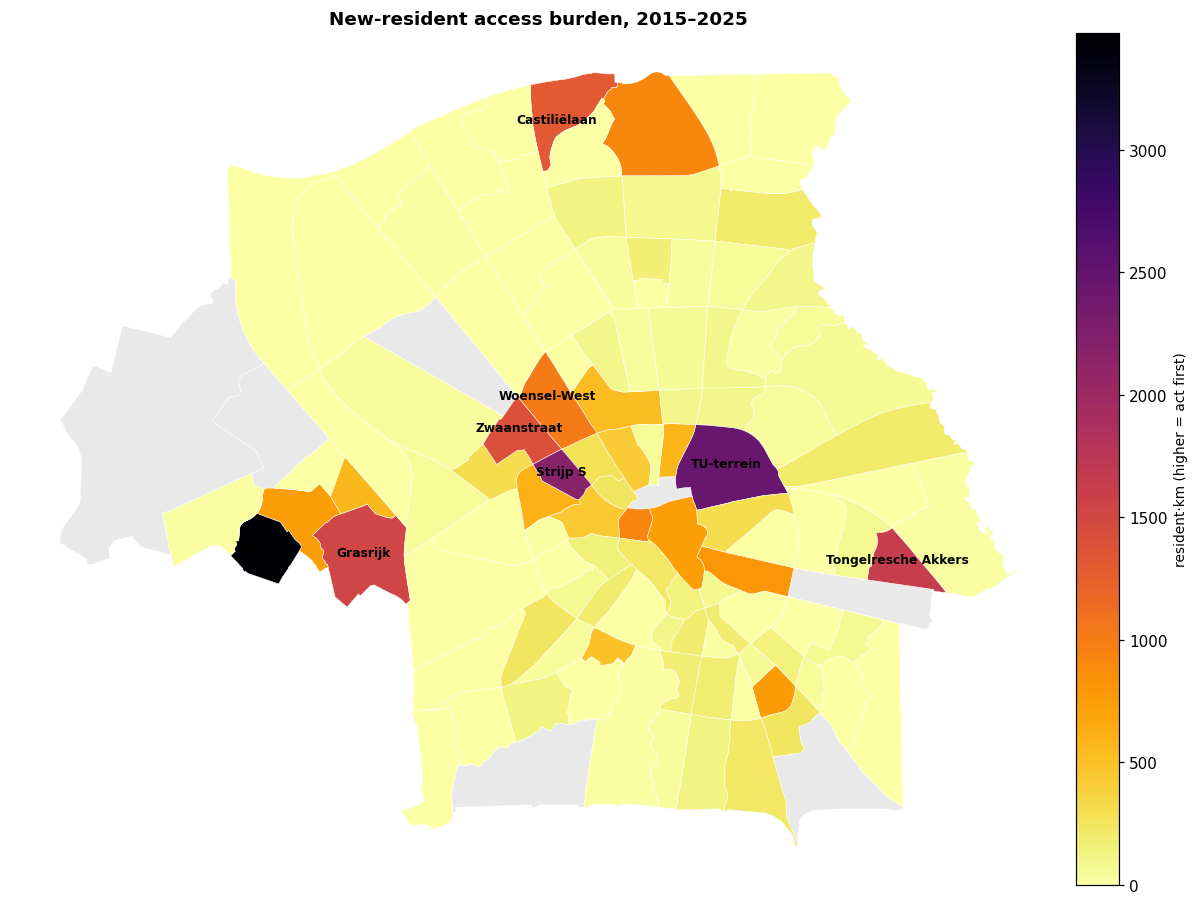

Top-8 neighbourhoods by new-resident access burden:
          buurtnaam  pop_growth  avg_essential  burden
          Waterrijk      1530.0            2.3  3475.3
         TU-terrein      2019.0            1.2  2451.6
           Strijp S      2419.0            0.9  2177.1
Tongelresche Akkers      1358.0            1.2  1629.6
           Grasrijk       804.0            1.9  1527.6
        Zwaanstraat      1119.0            1.3  1406.7
       Castiliëlaan       615.0            2.1  1309.1
       Woensel-West      1763.0            0.6  1007.4


In [13]:
gdf["burden"] = gdf["pop_growth"].clip(lower=0) * gdf["avg_essential"]

fig, ax = plt.subplots(figsize=(11, 10))
choropleth(ax, "burden", "New-resident access burden, 2015–2025",
           cmap="inferno_r", cbar_label="resident·km (higher = act first)")
for _, r in gdf.nlargest(8, "burden").iterrows():
    p = r.geometry.representative_point()
    ax.annotate(r["buurtnaam"], (p.x, p.y), fontsize=8, ha="center", weight="bold",
                color="black")
plt.tight_layout(); plt.show()

print("Top-8 neighbourhoods by new-resident access burden:")
cols = ["buurtnaam", "pop_growth", "avg_essential", "burden"]
print(gdf.nlargest(8, "burden")[cols].round(1).to_string(index=False))

## Reading these maps for RQ2

- **Maps 1 & 2** separate *demand* (population growth) from *supply* (facility
  access). The newly built western/edge neighbourhoods (e.g. the Meerhoven area —
  Waterrijk, Grasrijk, Meerrijk) light up on both.
- **Map 3** shows the gap is dominated by **train-station** and, in places,
  **secondary-school / hospital** distance — groceries and primary care are close
  almost everywhere. So "grow facilities faster" concretely means transport links
  and larger-catchment facilities, not corner shops.
- **Map 4** isolates a **housing** problem distinct from the facility problem:
  central, fully-occupied neighbourhoods where dwellings lagged population.
- **Map 5** combines growth and access into a single resident·km burden surface;
  its bright cluster (Waterrijk, TU-terrein, Strijp S, Tongelresche Akkers,
  Grasrijk) is the shortlist for municipal investment.

*All metrics are queried live from the RDF knowledge graph, so the maps refresh
automatically if the graph is regenerated.*